In [1]:
from datetime import datetime
from geopy import Nominatim
from tzwhere import tzwhere
from pytz import timezone, utc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from skyfield.api import Star, load, wgs84
from skyfield.data import stellarium
from skyfield.projections import build_stereographic_projection
from matplotlib.collections import LineCollection
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import Output

In [2]:
def load_custom_star_data(json_file_path):
    """
    Load the custom star dataset from a JSON file and additional data like
    ephemeris and constellation information.

    :param json_file_path: Path to the JSON file containing star data.
    :return: Tuple containing DataFrame of stars, ephemeris, and constellations.
    """
    # Load star data
    required_columns = [
        'hip', 'mag', 'ra_decdeg', 'dec_decdeg', 'plx', 'pmra', 'pmdec'
    ]
    df = pd.read_json(json_file_path)
    df = df[required_columns]
    df.columns = (
        'hip', 'magnitude', 'ra_degrees', 'dec_degrees',
        'parallax_mas', 'ra_mas_per_year', 'dec_mas_per_year',
    )
    numeric_columns = ['ra_degrees', 'dec_degrees', 'parallax_mas', 'ra_mas_per_year', 'dec_mas_per_year']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['magnitude'] = pd.to_numeric(df['magnitude'], errors='coerce')
    df = df.assign(ra_hours = df['ra_degrees'] / 15.0, epoch_year = 1991.25)
    df.set_index('hip', inplace=True)

    # Load ephemeris data
    eph = load('de421.bsp')

    # Load constellation data
    url = ('https://raw.githubusercontent.com/Stellarium/stellarium/master'
           '/skycultures/modern_st/constellationship.fab')
    with load.open(url) as f:
        constellations = stellarium.parse_constellations(f)

    return df, eph, constellations

# Usage
json_file_path = '../datasets/star_database.json'  # Replace with the path to your dataset
stars, eph, constellations = load_custom_star_data(json_file_path)


In [3]:
def collect_celestial_data(location, when):
    # Get latitude coordinates
    locator = Nominatim(user_agent='emaillegit04@gmail.com', timeout = 10)
    location = locator.geocode(location)
    lat, long = location.latitude, location.longitude
    
    # Convert date string into datetime object
    dt = datetime.strptime(when, '%Y-%m-%d %H:%M')

    # Define datetime and convert to UTC based on location coordinates
    timezone_str = tzwhere.tzwhere().tzNameAt(lat, long)
    local = timezone(timezone_str)
    utc_dt = local.localize(dt, is_dst=None).astimezone(utc)

    # Define observer using location coordinates and current UTC time
    t = load.timescale().from_datetime(utc_dt)
    observer = wgs84.latlon(latitude_degrees=lat, longitude_degrees=long).at(t)

    # An ephemeris on Sun and Earth positions.
    sun = eph['sun']
    earth = eph['earth']
    
    # And the constellation outlines list.
    edges = [edge for name, edges in constellations for edge in edges]
    edges_star1 = [star1 for star1, star2 in edges]
    edges_star2 = [star2 for star1, star2 in edges]

    
    # Define the angle and center the observation location by the angle
    position = observer.from_altaz(alt_degrees=90, az_degrees=0)
    ra, dec, distance = observer.radec()
    center_object = Star(ra=ra, dec=dec)

    # Build the stereographic projection
    center = earth.at(t).observe(center_object)
    projection = build_stereographic_projection(center)
    field_of_view_degrees = 180.0

    # Compute the x and y coordinates based on the projection
    star_positions = earth.at(t).observe(Star.from_dataframe(stars))
    stars['x'], stars['y'] = projection(star_positions)
    
    return stars, edges_star1, edges_star2
    
    
# call the above function with a given location and timestamp
location = 'Dublin, IE'
when = '2024-01-15 00:00'
stars, edges_star1, edges_star2 = collect_celestial_data(location, when)

c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


Text(value='Dublin', description='Location:')

Text(value='2024-01-15 00:00', description='Date & Time:')

IntSlider(value=12, description='Chart Size:', max=20, min=5)

IntSlider(value=200, description='Star Size:', max=300, min=100)

Checkbox(value=True, description='Draw Constellations')

Button(description='Update Chart', style=ButtonStyle())

Output()

c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


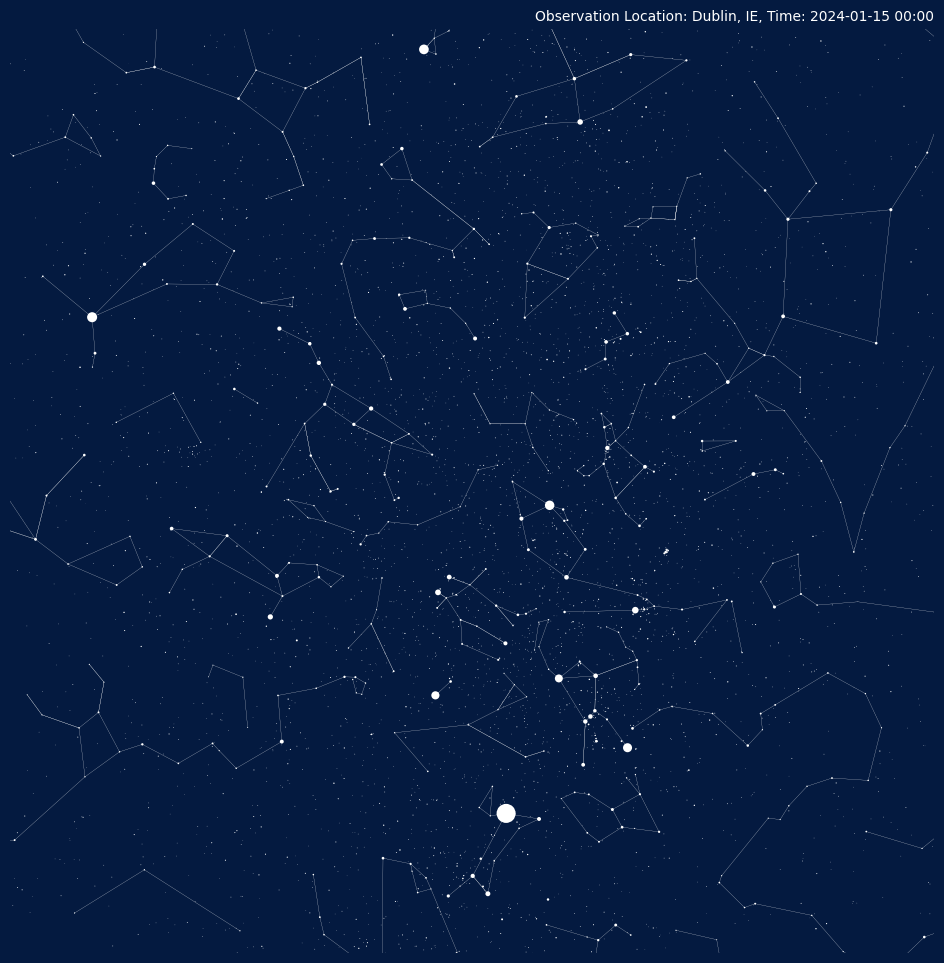

c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


c:\Users\rahul\AppData\Local\Programs\Python\Python39\lib\site-packages\tzwhere\tzwhere.py:62: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  self.timezoneNamesToPolygons[tzname] = WRAP(polys)


In [4]:
# Global variables to hold the figure and axes
# Global variables to hold the figure and axes
global fig, ax
fig, ax = None, None

# Function to create and update the interactive star chart
def create_interactive_star_chart(location, when, chart_size, max_star_size, draw_constellations):
    global fig, ax
    stars, edges_star1, edges_star2 = collect_celestial_data(location, when)
    
    # Define the number of stars and brightness of stars to include
    limiting_magnitude = 10
    bright_stars = (stars['magnitude'] <= limiting_magnitude)
    
    with chart_output:  # Assuming chart_output is a previously defined IPython Output widget
        clear_output(wait=True)  # Clear the existing chart output

        # Check if the figure and axes are already created
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(chart_size, chart_size), facecolor='#041A40')
        else:
            ax.clear()
            fig.set_size_inches(chart_size, chart_size)
            ax.set_facecolor('#041A40')
    
        # Draw the constellation lines only if draw_constellations is True
        if draw_constellations:
            # Filter edges to ensure both stars are in the DataFrame
            valid_edges = [(s1, s2) for s1, s2 in zip(edges_star1, edges_star2) if s1 in stars.index and s2 in stars.index]

            # Extract the star positions for the valid edges
            xy1 = [stars.loc[s1, ['x', 'y']].values for s1, s2 in valid_edges]
            xy2 = [stars.loc[s2, ['x', 'y']].values for s1, s2 in valid_edges]

            lines_xy = np.rollaxis(np.array([xy1, xy2]), 1)
            ax.add_collection(LineCollection(lines_xy, colors='#ffff', linewidths=0.15))
    
        # Draw the stars
        magnitude = stars['magnitude'][bright_stars]
        marker_size = max_star_size * 10 ** (magnitude / -2.5)
        ax.scatter(stars['x'][bright_stars], stars['y'][bright_stars],
                   s=marker_size, color='white', marker='.', linewidths=0, zorder=2)

        # Add other settings
        ax.set_aspect('equal')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.axis('off')
        when_datetime = datetime.strptime(when, '%Y-%m-%d %H:%M')
        ax.set_title(f"Observation Location: {location}, Time: {when_datetime.strftime('%Y-%m-%d %H:%M')}", loc='right', color='white', fontsize=10)

        display(fig)  # Display the figure inside the output widget

# Function to handle the update button click event
def update_star_chart(button):
    create_interactive_star_chart(location_input.value, when_input.value, 
                                  chart_size_input.value, max_star_size_input.value, 
                                  draw_constellations_checkbox.value)

# Widget creation
location_input = widgets.Text(value='Dublin', description='Location:')
when_input = widgets.Text(value='2024-01-15 00:00', description='Date & Time:')
chart_size_input = widgets.IntSlider(value=12, min=5, max=20, description='Chart Size:')
max_star_size_input = widgets.IntSlider(value=200, min=100, max=300, description='Star Size:')
draw_constellations_checkbox = widgets.Checkbox(value=True, description='Draw Constellations')

# Create the update button and assign the update function to its click event
update_button = widgets.Button(description='Update Chart')
update_button.on_click(update_star_chart)

# Create an output widget for the chart
chart_output = Output()

# Display the widgets and the chart output widget
display(location_input, when_input, chart_size_input, max_star_size_input, draw_constellations_checkbox, update_button)
display(chart_output)

# Initial call to create the default star chart
default_location = 'Dublin, IE'
default_when = '2024-01-15 00:00'
create_interactive_star_chart(default_location, default_when, 12, 200, True)


In [5]:
# # Attempt to centre the chart around Polaris
# # Since the chart is centred on Polaris, the "Rotation" of other stars are not visually apparent since Polaris itselt does not "Rotate" much at different times/ dates
# def collect_celestial_data(location, when, center_hip=11767.0):
#     print(f"Collecting data for {location} at {when}")  # Debug statement 1
#     locator = Nominatim(user_agent='emaillegit04@gmail.com', timeout=10)
#     location = locator.geocode(location)
#     lat, long = location.latitude, location.longitude

#     dt = datetime.strptime(when, '%Y-%m-%d %H:%M')

#     timezone_str = "Europe/Dublin"
#     local = timezone(timezone_str)
#     utc_dt = local.localize(dt, is_dst=None).astimezone(utc)

#     t = load.timescale().from_datetime(utc_dt)
#     observer = wgs84.latlon(latitude_degrees=lat, longitude_degrees=long).at(t)

#     # Debug statement 2: Check observer's datetime
#     print(f"Observer's datetime: {t.utc_datetime()}")
#     sun = eph['sun']
#     earth = eph['earth']

#     edges = [edge for name, edges in constellations for edge in edges]
#     edges_star1 = [star1 for star1, star2 in edges]
#     edges_star2 = [star2 for star1, star2 in edges]

#     # Center on Polaris with RA in degrees converted to hours
#     polaris_position = stars.loc[center_hip]
#     ra_hours_polaris = polaris_position['ra_degrees'] / 15.0  # Convert RA from degrees to hours
#     polaris = Star(ra_hours=ra_hours_polaris, dec_degrees=polaris_position['dec_degrees'])
#     center = earth.at(t).observe(polaris)
#     projection = build_stereographic_projection(center)
#     field_of_view_degrees = 180.0

#     star_positions = earth.at(t).observe(Star.from_dataframe(stars))
#     stars['x'], stars['y'] = projection(star_positions)

#     # Debug statement 3: Verify the projection update
#     print(f"Sample star projection: {stars.loc[center_hip, ['x', 'y']]}")
#     return stars, edges_star1, edges_star2